<a href="https://colab.research.google.com/github/LinglinNero/MSSP607/blob/main/Participation_Acitivity_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#connect to github file
from google.colab import userdata
import os

github_token = userdata.get('Git_Hub')
owner = 'LinglinNero' # Replace with the GitHub repository owner
repository = 'MSSP607' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
!git clone {clone_url}

fatal: destination path 'MSSP607' already exists and is not an empty directory.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/MSSP607/Modules/Module12/Student Performance Data.csv')

In [4]:
males = df[df['gender'] == 'male']
complete = males[males['test preparation course'] == 'completed']['total score']
none = males[males['test preparation course'] == 'none']['total score']

stat_comp, p_comp = stats.normaltest(complete)
stat_comp, p_none = stats.normaltest(none)

print('normal test complete', p_comp)
print('normal test none', p_none)

normal test complete 0.07478297328266548
normal test none 0.28844175654581156


In [5]:
#Since both distributions are approximately normal, we can proceed with a standard T-test
mean_completed = complete.mean()
mean_none = none.mean()
t_stat, p_val = stats.ttest_ind(complete, none, equal_var=False)

print('mean completed', mean_completed)
print('mean none', mean_none)
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha:
    print("\nConclusion: Reject the Null Hypothesis.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis.")

mean completed 212.3448275862069
mean none 189.13311688311688

T-statistic: 6.1814
P-value: 1.7264e-09

Conclusion: Reject the Null Hypothesis.


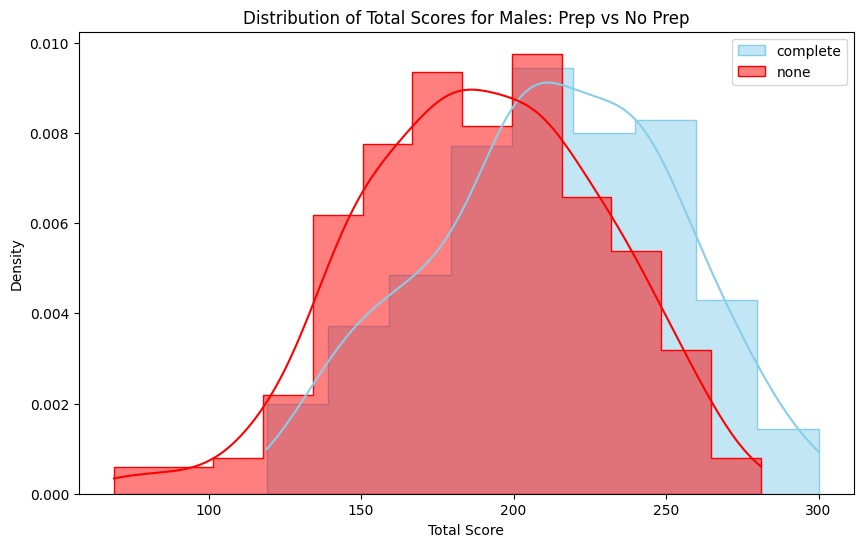

In [6]:
#plot
plt.figure(figsize=(10, 6))
sns.histplot(complete, color = 'skyblue', label = 'complete', kde=True, stat="density", element="step")
sns.histplot(none, color = 'red', label = 'none', kde=True, stat="density", element="step")
plt.title('Distribution of Total Scores for Males: Prep vs No Prep')
plt.xlabel('Total Score')
plt.legend()
plt.show()


In [7]:
#There is a statistically significant difference in performance.
#Males who completed the test preparation course performed significantly better than those who did not.

In [8]:
#Are there any other differences that are of interest?
#except their mean score difference, I see that their bell curve shape are very similar, which means while the preparation course shifted the scores higher,
#it did not make the scores more consistent or more variable. The bell curves for both groups have roughly the same width